# 🧠 Análise Preditiva de Churn — TensorFlow + SQLAlchemy
**Banco de dados:** Contoso Retail DW (SQL Server)  
**Conexão:** SQLAlchemy (ORM profissional)  
**Algoritmo:** Rede Neural com TensorFlow/Keras  
**Autor:** Jefferson da Silva Araújo  

---

## 📋 Por que TensorFlow + SQLAlchemy?

| Ferramenta | Por que usar |
|---|---|
| **SQLAlchemy** | ORM padrão do mercado — mais robusto que pyodbc puro, suporte a múltiplos bancos |
| **TensorFlow/Keras** | Framework de Deep Learning do Google — redes neurais para padrões complexos |
| **Combinação** | Arquitetura usada em empresas de médio/grande porte |

## 🗂️ Estrutura do Notebook
1. Instalação e importações
2. Conexão com SQL Server via SQLAlchemy
3. Análise Exploratória de Dados (EDA)
4. Pré-processamento e normalização
5. Construção da Rede Neural com Keras
6. Treinamento com callbacks
7. Avaliação completa
8. Comparação Random Forest vs Rede Neural
9. Salvando o modelo para produção

---
## 1️⃣ Instalação e Importações

> **Nota:** Execute a célula de instalação apenas na primeira vez.

In [ ]:
# ── Instalação das dependências (execute apenas uma vez) ──────────────────
# !pip install sqlalchemy pyodbc tensorflow scikit-learn pandas numpy matplotlib seaborn

In [1]:
# ── Conexão com banco de dados ────────────────────────────────────────────
from sqlalchemy import create_engine, text
from sqlalchemy.engine import URL

# ── Manipulação de dados ──────────────────────────────────────────────────
import pandas as pd
import numpy as np

# ── Visualização ──────────────────────────────────────────────────────────
import matplotlib.pyplot as plt
import seaborn as sns

# ── Machine Learning — Pré-processamento ─────────────────────────────────
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (
    classification_report, confusion_matrix,
    ConfusionMatrixDisplay, roc_auc_score, roc_curve,
    accuracy_score
)
from sklearn.ensemble import RandomForestClassifier

# ── TensorFlow / Keras ────────────────────────────────────────────────────
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers, callbacks, regularizers
from tensorflow.keras.utils import plot_model

# ── Utilitários ───────────────────────────────────────────────────────────
import warnings
import os
warnings.filterwarnings('ignore')
os.environ['TF_CPP_MIN_LOG_LEVEL'] = '3'  # Reduz logs verbosos do TF

# ── Seed para reprodutibilidade ───────────────────────────────────────────
SEED = 42
np.random.seed(SEED)
tf.random.set_seed(SEED)

# ── Configuração visual ───────────────────────────────────────────────────
sns.set_theme(style='whitegrid')
plt.rcParams['figure.figsize'] = [10, 6]
plt.rcParams['axes.spines.top'] = False
plt.rcParams['axes.spines.right'] = False

print('✅ Bibliotecas carregadas com sucesso!')
print(f'   TensorFlow : {tf.__version__}')
print(f'   Keras      : {keras.__version__}')
print(f'   pandas     : {pd.__version__}')
print(f'   numpy      : {np.__version__}')
print(f'\n   GPU disponível: {len(tf.config.list_physical_devices("GPU")) > 0}')

✅ Bibliotecas carregadas com sucesso!
   TensorFlow : 2.21.0
   Keras      : 3.14.1
   pandas     : 2.3.1
   numpy      : 2.3.2

   GPU disponível: False


---
## 2️⃣ Conexão com SQL Server via SQLAlchemy

### 🔌 SQLAlchemy vs pyodbc

| | pyodbc | SQLAlchemy |
|---|---|---|
| Nível | Baixo nível | ORM (alto nível) |
| Portabilidade | SQL Server apenas | MySQL, PostgreSQL, SQLite, Oracle... |
| Integração Pandas | Manual | Nativa com `read_sql` |
| Uso no mercado | Scripts simples | Aplicações e APIs |
| Connection Pool | Manual | Automático |

> **SQLAlchemy** é o padrão usado em aplicações Python profissionais, APIs FastAPI e frameworks como Django e Flask.

In [2]:
# ── Configuração da conexão via SQLAlchemy ────────────────────────────────
# URL.create() é a forma moderna e segura de criar a string de conexão
# Evita problemas com caracteres especiais na senha

connection_url = URL.create(
    drivername='mssql+pyodbc',        # Driver: SQL Server via pyodbc
    host='ARAUJO',                     # Nome do servidor
    database='ContosoRetailDW',        # Banco de dados
    query={
        'driver': 'SQL Server',        # Driver ODBC instalado
        'Trusted_Connection': 'yes',   # Autenticação Windows
    }
)

print('🔌 Criando engine SQLAlchemy...')

# ── Engine — objeto principal do SQLAlchemy ───────────────────────────────
# O Engine gerencia o pool de conexões automaticamente
# pool_pre_ping=True verifica se a conexão ainda está ativa antes de usar
engine = create_engine(
    connection_url,
    pool_pre_ping=True,
    echo=False  # True para ver os SQLs gerados (útil para debug)
)

# ── Teste de conexão ──────────────────────────────────────────────────────
try:
    with engine.connect() as conn: # garante que a conexão com o banco será fechada corretamente após o bloco de código, evitando vazamento de recursos
        resultado = conn.execute(text('SELECT @@VERSION'))
        versao = resultado.fetchone()[0]
        print(f'✅ Conexão estabelecida com sucesso!')
        print(f'   Servidor: {versao[:50]}...')
except Exception as e:
    print(f'❌ Erro na conexão: {e}')

# ── Carregamento dos dados via SQLAlchemy ─────────────────────────────────
# Usamos a mesma View criada anteriormente no SQL Server
# O SQLAlchemy usa o engine como contexto de conexão
print('\n📥 Carregando dados da View...')

QUERY = """
    SELECT 
        CustomerKey,
        Idade,
        TotalItensComprados,
        TotalItensDevolvidos,
        DiasDesdeUltimaCompra,
        DeixouDeComprar
    FROM dbo.vw_Dados_Treinamento_Churn
"""

# pd.read_sql aceita o engine diretamente — sem precisar abrir/fechar conexão
with engine.connect() as conn:
    df = pd.read_sql(text(QUERY), conn)

print(f'✅ {len(df):,} registros carregados!')
print(f'\n📊 Primeiros registros:')
df.head()

🔌 Criando engine SQLAlchemy...
✅ Conexão estabelecida com sucesso!
   Servidor: Microsoft SQL Server 2022 (RTM) - 16.0.1000.6 (X64...

📥 Carregando dados da View...
✅ 18,484 registros carregados!

📊 Primeiros registros:


,CustomerKey,Idade,TotalItensComprados,TotalItensDevolvidos,DiasDesdeUltimaCompra,DeixouDeComprar
0,3177,80,211,0,6007,0
1,3179,80,249,1,6007,0
2,3184,73,217,2,6010,0
3,3186,74,222,1,6007,0
4,3193,76,256,1,6007,0


In [3]:
# ── Verificação inicial dos dados ─────────────────────────────────────────
print('=' * 55)
print(' VISÃO GERAL DO DATASET')
print('=' * 55)
print(f' Linhas    : {df.shape[0]:>10,}')
print(f' Colunas   : {df.shape[1]:>10}')
print(f' Nulos     : {df.isnull().sum().sum():>10}')
print('=' * 55)
print(f'\n Distribuição do Target:')
vc = df['DeixouDeComprar'].value_counts()
pct = df['DeixouDeComprar'].value_counts(normalize=True) * 100
print(f'   Ativo (0) : {vc[0]:>6,} ({pct[0]:.1f}%)')
print(f'   Churn (1) : {vc[1]:>6,} ({pct[1]:.1f}%)')

df.describe().round(2)

 VISÃO GERAL DO DATASET
 Linhas    :     18,484
 Colunas   :          6
 Nulos     :          0

 Distribuição do Target:
   Ativo (0) : 16,474 (89.1%)
   Churn (1) :  2,010 (10.9%)


,CustomerKey,Idade,TotalItensComprados,TotalItensDevolvidos,DiasDesdeUltimaCompra,DeixouDeComprar
count,18484.00,18484.00,18484.00,18484.00,18484.00,18484.00
mean,9242.50,64.42,152.35,0.87,6048.65,0.11
std,5336.02,11.25,59.62,1.02,104.08,0.31
min,1.00,46.00,68.00,0.00,6000.00,0.00
25%,4621.75,56.00,104.00,0.00,6004.00,0.00
50%,9242.50,63.00,123.00,1.00,6011.00,0.00
75%,13863.25,72.00,195.00,1.00,6032.00,0.00
max,18484.00,116.00,376.00,8.00,6378.00,1.00


---
## 3️⃣ Análise Exploratória de Dados (EDA)

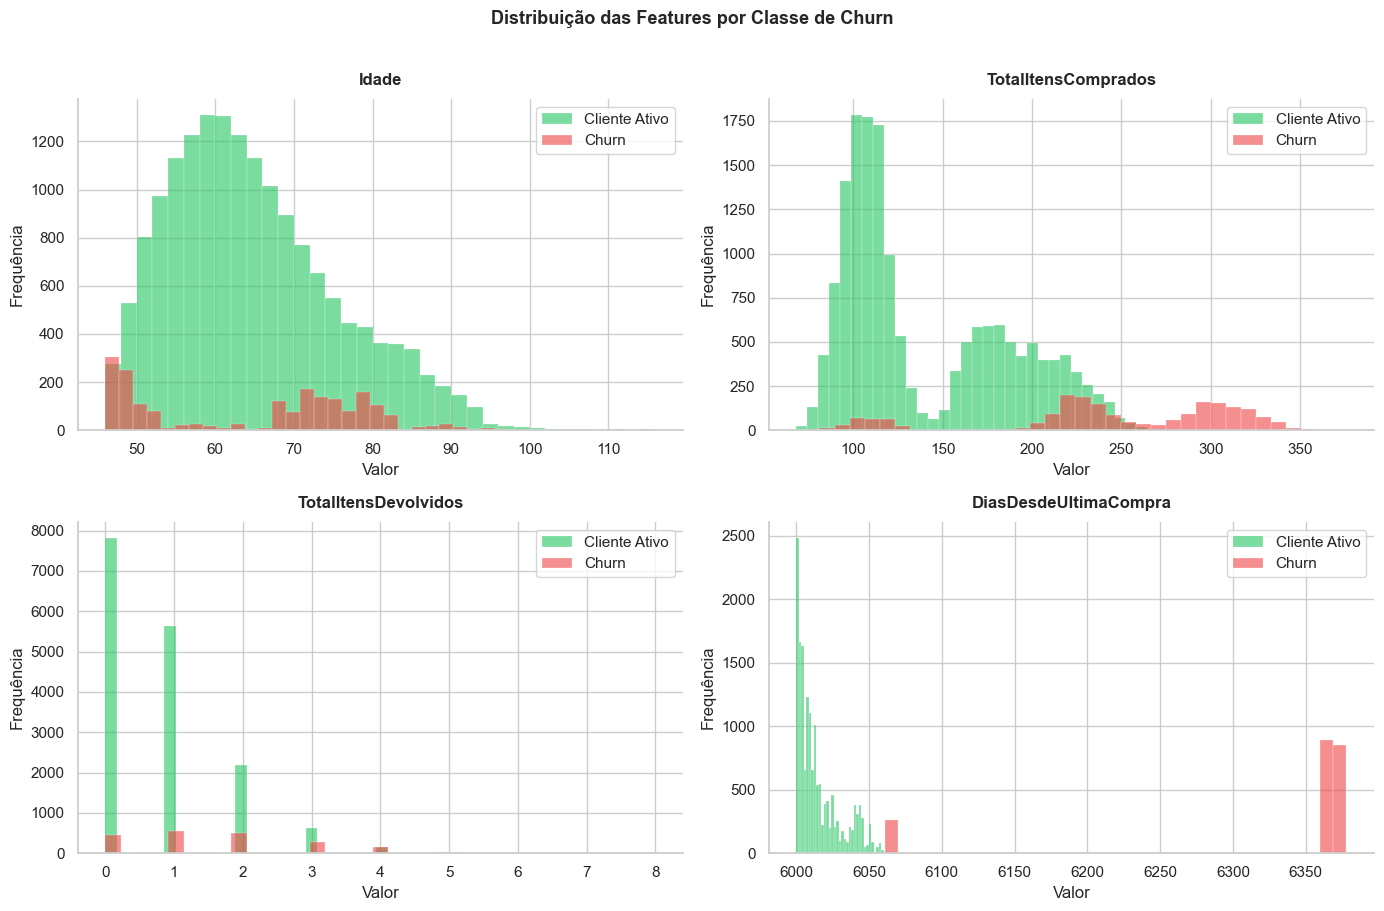

In [4]:
# ── Distribuição das features por classe ─────────────────────────────────
features_plot = ['Idade', 'TotalItensComprados', 'TotalItensDevolvidos', 'DiasDesdeUltimaCompra']
cores = {0: '#22c55e', 1: '#ef4444'}

fig, axes = plt.subplots(2, 2, figsize=(14, 9))
axes = axes.flatten()

for i, feat in enumerate(features_plot):
    for classe, cor in cores.items():
        label = 'Cliente Ativo' if classe == 0 else 'Churn'
        subset = df[df['DeixouDeComprar'] == classe][feat]
        axes[i].hist(subset, bins=35, alpha=0.6, color=cor,
                    label=label, edgecolor='white', linewidth=0.3)
    axes[i].set_title(feat, fontweight='bold', pad=10)
    axes[i].set_xlabel('Valor')
    axes[i].set_ylabel('Frequência')
    axes[i].legend()

plt.suptitle('Distribuição das Features por Classe de Churn',
             fontsize=13, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()

---
## 4️⃣ Pré-processamento e Normalização

### ⚡ Por que normalizar para Redes Neurais?

Redes Neurais são **muito sensíveis à escala das features**. Sem normalização:
- Features com valores grandes dominam o aprendizado
- Gradientes ficam instáveis (explodindo ou desaparecendo)
- O modelo converge mais lento ou não converge

**StandardScaler** transforma cada feature para média=0 e desvio padrão=1.

In [5]:
# ── Separação de Features e Target ───────────────────────────────────────
FEATURES = ['Idade', 'TotalItensComprados', 'TotalItensDevolvidos']
TARGET   = 'DeixouDeComprar'

X = df[FEATURES].values  # .values converte para array NumPy (necessário para TF)
y = df[TARGET].values

# ── Divisão Treino / Validação / Teste ────────────────────────────────────
# Estratégia: 70% treino | 15% validação | 15% teste
# A validação é usada durante o treinamento para monitorar overfitting

X_treino, X_temp, y_treino, y_temp = train_test_split(
    X, y, test_size=0.30, random_state=SEED, stratify=y
)
X_val, X_teste, y_val, y_teste = train_test_split(
    X_temp, y_temp, test_size=0.50, random_state=SEED, stratify=y_temp
)

print('📊 Divisão dos dados:')
print(f'   Treino    : {len(X_treino):>6,} registros ({len(X_treino)/len(X)*100:.0f}%)')
print(f'   Validação : {len(X_val):>6,} registros ({len(X_val)/len(X)*100:.0f}%)')
print(f'   Teste     : {len(X_teste):>6,} registros ({len(X_teste)/len(X)*100:.0f}%)')

# ── Normalização com StandardScaler ──────────────────────────────────────
# IMPORTANTE: o scaler aprende APENAS com os dados de treino
# Aplicamos a transformação no val e teste sem re-treinar o scaler
# Isso evita Data Leakage (vazamento de informação do teste para o treino)

scaler = StandardScaler()
X_treino_norm = scaler.fit_transform(X_treino)  # Aprende e transforma
X_val_norm    = scaler.transform(X_val)          # Só transforma
X_teste_norm  = scaler.transform(X_teste)        # Só transforma

print(f'\n✅ Normalização aplicada (StandardScaler)')
print(f'   Média antes  : {X_treino.mean(axis=0).round(2)}')
print(f'   Média depois : {X_treino_norm.mean(axis=0).round(4)}')
print(f'   Std depois   : {X_treino_norm.std(axis=0).round(4)}')

# ── Peso das classes para lidar com desbalanceamento ─────────────────────
# Como temos ~88% ativos e ~12% churn, damos mais peso à classe minoritária
total = len(y_treino)
n_0   = np.sum(y_treino == 0)
n_1   = np.sum(y_treino == 1)
peso_0 = total / (2 * n_0)
peso_1 = total / (2 * n_1)
class_weight = {0: peso_0, 1: peso_1}

print(f'\n⚖️  Pesos das classes (para desbalanceamento):')
print(f'   Classe 0 (Ativo) : {peso_0:.4f}')
print(f'   Classe 1 (Churn) : {peso_1:.4f}')

📊 Divisão dos dados:
   Treino    : 12,938 registros (70%)
   Validação :  2,773 registros (15%)
   Teste     :  2,773 registros (15%)

✅ Normalização aplicada (StandardScaler)
   Média antes  : [ 64.39 152.19   0.87]
   Média depois : [ 0. -0. -0.]
   Std depois   : [1. 1. 1.]

⚖️  Pesos das classes (para desbalanceamento):
   Classe 0 (Ativo) : 0.5610
   Classe 1 (Churn) : 4.5977


---
## 5️⃣ Construção da Rede Neural com Keras

### 🧠 Arquitetura utilizada

```
Input (3 features)
    ↓
Dense(64) + ReLU + BatchNorm + Dropout(0.3)
    ↓
Dense(32) + ReLU + BatchNorm + Dropout(0.2)
    ↓
Dense(16) + ReLU
    ↓
Dense(1)  + Sigmoid  →  Probabilidade de Churn [0, 1]
```

### Explicação das camadas:
- **Dense** → camada totalmente conectada — aprende padrões nos dados
- **ReLU** → função de ativação — introduz não-linearidade
- **BatchNormalization** → estabiliza e acelera o treinamento
- **Dropout** → desliga neurônios aleatoriamente — previne overfitting
- **Sigmoid** → saída entre 0 e 1 — interpreta como probabilidade

In [6]:
# ── Construção da Rede Neural ─────────────────────────────────────────────
def criar_modelo(n_features, learning_rate=0.001):
    """
    Cria e compila a rede neural para classificação binária.
    
    Parâmetros:
        n_features    : número de features de entrada
        learning_rate : taxa de aprendizado do otimizador
    
    Retorna:
        modelo compilado pronto para treinamento
    """
    # Usando a API Funcional do Keras (mais flexível que Sequential)
    inputs = keras.Input(shape=(n_features,), name='entrada')
    
    # ── Bloco 1 ───────────────────────────────────────────────────────────
    x = layers.Dense(
        64, activation='relu', name='dense_1',
        kernel_regularizer=regularizers.l2(0.001)  # Regularização L2 — penaliza pesos grandes
    )(inputs)
    x = layers.BatchNormalization(name='batchnorm_1')(x)  # Normaliza saída da camada
    x = layers.Dropout(0.3, name='dropout_1')(x)           # Desliga 30% dos neurônios
    
    # ── Bloco 2 ───────────────────────────────────────────────────────────
    x = layers.Dense(
        32, activation='relu', name='dense_2',
        kernel_regularizer=regularizers.l2(0.001)
    )(x)
    x = layers.BatchNormalization(name='batchnorm_2')(x)
    x = layers.Dropout(0.2, name='dropout_2')(x)           # Desliga 20% dos neurônios
    
    # ── Bloco 3 ───────────────────────────────────────────────────────────
    x = layers.Dense(16, activation='relu', name='dense_3')(x)
    
    # ── Camada de saída ───────────────────────────────────────────────────
    # Sigmoid → saída entre 0 e 1 (probabilidade de churn)
    outputs = layers.Dense(1, activation='sigmoid', name='saida')(x)
    
    modelo = keras.Model(inputs=inputs, outputs=outputs, name='ChurnNet')
    
    # ── Compilação ────────────────────────────────────────────────────────
    modelo.compile(
        optimizer=keras.optimizers.Adam(learning_rate=learning_rate),
        loss='binary_crossentropy',  # Loss padrão para classificação binária
        metrics=[
            'accuracy',
            keras.metrics.AUC(name='auc'),
            keras.metrics.Precision(name='precision'),
            keras.metrics.Recall(name='recall')
        ]
    )
    return modelo


# ── Instanciar o modelo ───────────────────────────────────────────────────
modelo_nn = criar_modelo(n_features=len(FEATURES))

# ── Resumo da arquitetura ─────────────────────────────────────────────────
modelo_nn.summary()

total_params = modelo_nn.count_params()
print(f'\n✅ Modelo criado com {total_params:,} parâmetros treináveis')

Model: "ChurnNet"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ entrada (InputLayer)                 │ (None, 3)                   │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_1 (Dense)                      │ (None, 64)                  │             256 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ batchnorm_1 (BatchNormalization)     │ (None, 64)                  │             256 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_1 (Dropout)                  │ (None, 64)                  │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_2 (Dense)                      │ (None, 32)                  │           2,080 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ batchnorm_2 (BatchNormalization)     │ (None, 32)                  │             128 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_2 (Dropout)                  │ (None, 32)                  │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_3 (Dense)                      │ (None, 16)                  │             528 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ saida (Dense)                        │ (None, 1)                   │              17 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 3,265 (12.75 KB)

 Trainable params: 3,073 (12.00 KB)

 Non-trainable params: 192 (768.00 B)


✅ Modelo criado com 3,265 parâmetros treináveis


---
## 6️⃣ Treinamento com Callbacks

### 📡 Callbacks utilizados:
- **EarlyStopping** → para o treino quando a validação não melhora (evita overfitting)
- **ReduceLROnPlateau** → reduz a taxa de aprendizado automaticamente quando estagna
- **ModelCheckpoint** → salva o melhor modelo durante o treino

In [7]:
# ── Configuração dos Callbacks ────────────────────────────────────────────

# EarlyStopping: monitora val_auc e para se não melhorar por 15 épocas
early_stop = callbacks.EarlyStopping(
    monitor='val_auc',
    patience=15,           # Espera 15 épocas sem melhora antes de parar
    restore_best_weights=True,  # Volta para os melhores pesos automaticamente
    mode='max',
    verbose=1
)

# ReduceLROnPlateau: reduz learning rate pela metade se val_loss estagna
reduce_lr = callbacks.ReduceLROnPlateau(
    monitor='val_loss',
    factor=0.5,            # Multiplica o LR por 0.5
    patience=8,            # Espera 8 épocas antes de reduzir
    min_lr=1e-6,           # Learning rate mínimo
    verbose=1
)

# ModelCheckpoint: salva o melhor modelo em disco
checkpoint = callbacks.ModelCheckpoint(
    filepath='melhor_modelo_churn.keras',
    monitor='val_auc',
    save_best_only=True,
    mode='max',
    verbose=0
)

# ── Treinamento ───────────────────────────────────────────────────────────
print('🚀 Iniciando treinamento da Rede Neural...')
print('=' * 55)

historico = modelo_nn.fit(
    X_treino_norm, y_treino,
    epochs=100,                          # Máximo de 100 épocas
    batch_size=256,                      # 256 amostras por atualização de pesos
    validation_data=(X_val_norm, y_val), # Dados de validação
    class_weight=class_weight,           # Peso para classes desbalanceadas
    callbacks=[early_stop, reduce_lr, checkpoint],
    verbose=1
)

epocas_usadas = len(historico.history['loss'])
print(f'\n✅ Treinamento concluído em {epocas_usadas} épocas!')

🚀 Iniciando treinamento da Rede Neural...
Epoch 1/100
51/51 ━━━━━━━━━━━━━━━━━━━━ 6s 26ms/step - accuracy: 0.6859 - auc: 0.7845 - loss: 0.6131 - precision: 0.2187 - recall: 0.7342 - val_accuracy: 0.9261 - val_auc: 0.8702 - val_loss: 0.5776 - val_precision: 0.6932 - val_recall: 0.5762 - learning_rate: 0.0010
Epoch 2/100
51/51 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - accuracy: 0.8320 - auc: 0.8849 - loss: 0.4609 - precision: 0.3754 - recall: 0.8216 - val_accuracy: 0.9376 - val_auc: 0.8937 - val_loss: 0.4406 - val_precision: 0.8957 - val_recall: 0.4834 - learning_rate: 0.0010
Epoch 3/100
51/51 ━━━━━━━━━━━━━━━━━━━━ 1s 10ms/step - accuracy: 0.8801 - auc: 0.9025 - loss: 0.4145 - precision: 0.4709 - recall: 0.8273 - val_accuracy: 0.9394 - val_auc: 0.9029 - val_loss: 0.3693 - val_precision: 0.9036 - val_recall: 0.4967 - learning_rate: 0.0010
Epoch 4/100
51/51 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - accuracy: 0.8955 - auc: 0.9106 - loss: 0.3953 - precision: 0.5122 - recall: 0.8230 - val_accuracy: 0.9398 - 

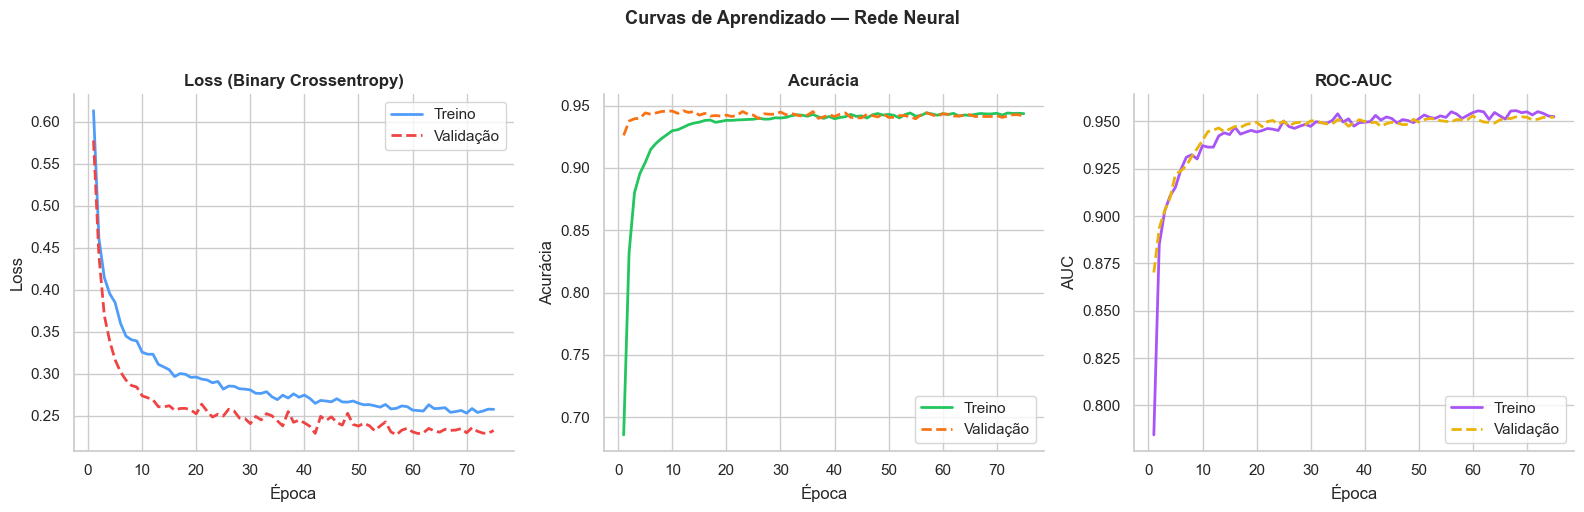

In [8]:
# ── Curvas de Aprendizado ─────────────────────────────────────────────────
# Mostra como o modelo evoluiu durante o treinamento
# Overfitting: treino melhora mas validação piora
# Underfitting: ambos ficam ruins

hist = historico.history
epocas = range(1, len(hist['loss']) + 1)

fig, axes = plt.subplots(1, 3, figsize=(16, 5))

# Loss
axes[0].plot(epocas, hist['loss'],     color='#4f9cf9', label='Treino',    linewidth=2)
axes[0].plot(epocas, hist['val_loss'], color='#ef4444', label='Validação', linewidth=2, linestyle='--')
axes[0].set_title('Loss (Binary Crossentropy)', fontweight='bold')
axes[0].set_xlabel('Época')
axes[0].set_ylabel('Loss')
axes[0].legend()

# Acurácia
axes[1].plot(epocas, hist['accuracy'],     color='#22c55e', label='Treino',    linewidth=2)
axes[1].plot(epocas, hist['val_accuracy'], color='#f97316', label='Validação', linewidth=2, linestyle='--')
axes[1].set_title('Acurácia', fontweight='bold')
axes[1].set_xlabel('Época')
axes[1].set_ylabel('Acurácia')
axes[1].legend()

# AUC
axes[2].plot(epocas, hist['auc'],     color='#a855f7', label='Treino',    linewidth=2)
axes[2].plot(epocas, hist['val_auc'], color='#eab308', label='Validação', linewidth=2, linestyle='--')
axes[2].set_title('ROC-AUC', fontweight='bold')
axes[2].set_xlabel('Época')
axes[2].set_ylabel('AUC')
axes[2].legend()

plt.suptitle('Curvas de Aprendizado — Rede Neural', fontsize=13, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

---
## 7️⃣ Avaliação Completa do Modelo

In [9]:
# ── Avaliação na base de teste ────────────────────────────────────────────
print('🔍 Avaliando modelo na base de TESTE...')
resultado_teste = modelo_nn.evaluate(X_teste_norm, y_teste, verbose=0)
metricas_nomes  = modelo_nn.metrics_names

print('\n' + '=' * 55)
print(' RESULTADOS — Rede Neural (TensorFlow/Keras)')
print('=' * 55)
for nome, val in zip(metricas_nomes, resultado_teste):
    print(f'   {nome:<15} : {val:.4f}')
print('=' * 55)

# ── Previsões ─────────────────────────────────────────────────────────────
y_pred_prob_nn = modelo_nn.predict(X_teste_norm, verbose=0).flatten()
y_pred_nn      = (y_pred_prob_nn >= 0.5).astype(int)  # Threshold padrão: 0.5

print('\n📊 Classification Report — Rede Neural:')
print(classification_report(
    y_teste, y_pred_nn,
    target_names=['Cliente Ativo (0)', 'Churn (1)']
))

auc_nn = roc_auc_score(y_teste, y_pred_prob_nn)
print(f'ROC-AUC Score: {auc_nn:.4f}')

🔍 Avaliando modelo na base de TESTE...

 RESULTADOS — Rede Neural (TensorFlow/Keras)
   loss            : 0.2341
   compile_metrics : 0.9445

📊 Classification Report — Rede Neural:
                   precision    recall  f1-score   support

Cliente Ativo (0)       0.98      0.95      0.97      2472
        Churn (1)       0.69      0.87      0.77       301

         accuracy                           0.94      2773
        macro avg       0.84      0.91      0.87      2773
     weighted avg       0.95      0.94      0.95      2773

ROC-AUC Score: 0.9572


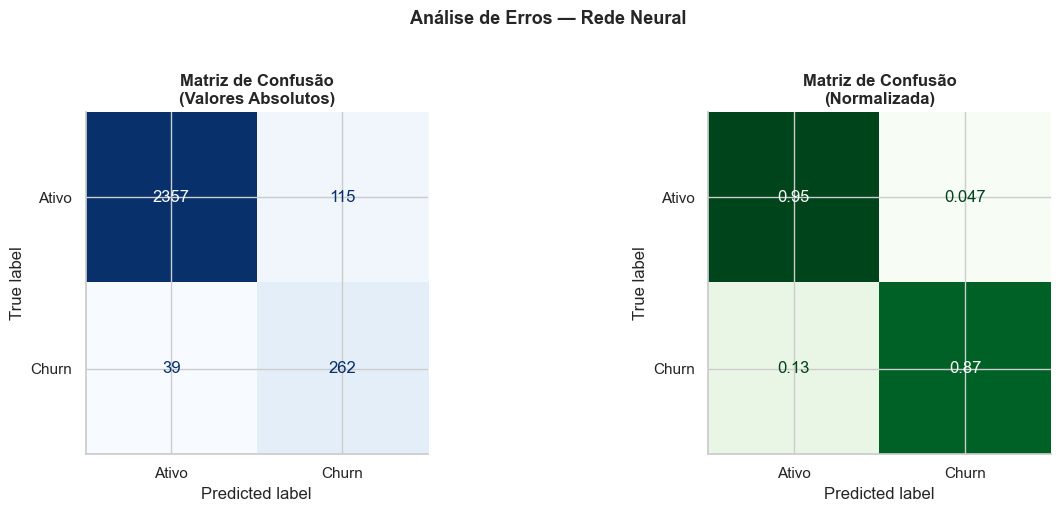

In [10]:
# ── Matriz de Confusão ────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

cm_nn = confusion_matrix(y_teste, y_pred_nn)
ConfusionMatrixDisplay(cm_nn, display_labels=['Ativo', 'Churn']).plot(
    ax=axes[0], cmap='Blues', colorbar=False
)
axes[0].set_title('Matriz de Confusão\n(Valores Absolutos)', fontweight='bold')

cm_nn_norm = confusion_matrix(y_teste, y_pred_nn, normalize='true')
ConfusionMatrixDisplay(cm_nn_norm, display_labels=['Ativo', 'Churn']).plot(
    ax=axes[1], cmap='Greens', colorbar=False
)
axes[1].set_title('Matriz de Confusão\n(Normalizada)', fontweight='bold')

plt.suptitle('Análise de Erros — Rede Neural', fontsize=13, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

---
## 8️⃣ Comparação: Random Forest vs Rede Neural

Treinamos o Random Forest com os mesmos dados para uma comparação justa.

🌲 Treinando Random Forest para comparação...


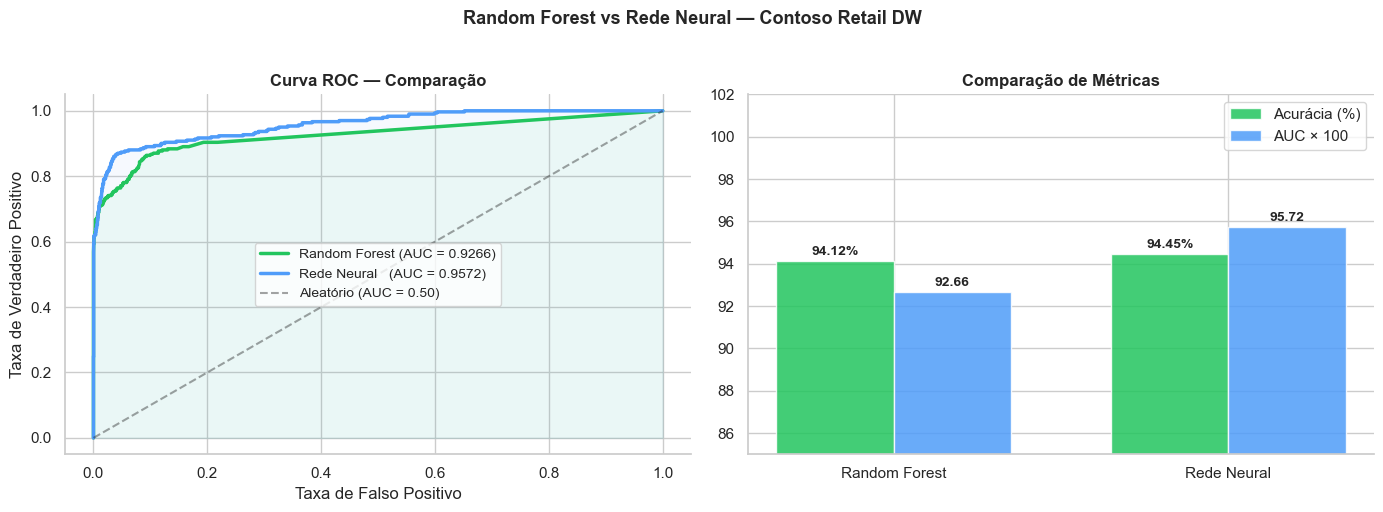


 COMPARAÇÃO FINAL
 Modelo          | Acurácia  | ROC-AUC
 Random Forest   |   94.12%  | 0.9266
 Rede Neural     |   94.45%  | 0.9572
 🏆 Melhor AUC: Rede Neural


In [11]:
# ── Treinar Random Forest para comparação ────────────────────────────────
print('🌲 Treinando Random Forest para comparação...')
rf = RandomForestClassifier(
    n_estimators=100, random_state=SEED,
    class_weight='balanced', n_jobs=-1
)
# Random Forest não precisa de normalização
X_treino_rf = np.vstack([X_treino, X_val])  # Treina com treino + validação
y_treino_rf = np.concatenate([y_treino, y_val])
rf.fit(X_treino_rf, y_treino_rf)

y_pred_prob_rf = rf.predict_proba(X_teste)[:, 1]
y_pred_rf      = rf.predict(X_teste)
auc_rf         = roc_auc_score(y_teste, y_pred_prob_rf)
acc_rf         = accuracy_score(y_teste, y_pred_rf)

acc_nn = accuracy_score(y_teste, y_pred_nn)

# ── Comparação visual ─────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Curvas ROC lado a lado
fpr_rf, tpr_rf, _ = roc_curve(y_teste, y_pred_prob_rf)
fpr_nn, tpr_nn, _ = roc_curve(y_teste, y_pred_prob_nn)

axes[0].plot(fpr_rf, tpr_rf, color='#22c55e', linewidth=2.5,
             label=f'Random Forest (AUC = {auc_rf:.4f})')
axes[0].plot(fpr_nn, tpr_nn, color='#4f9cf9', linewidth=2.5,
             label=f'Rede Neural   (AUC = {auc_nn:.4f})')
axes[0].plot([0,1],[0,1], 'k--', alpha=0.4, label='Aleatório (AUC = 0.50)')
axes[0].fill_between(fpr_rf, tpr_rf, alpha=0.05, color='#22c55e')
axes[0].fill_between(fpr_nn, tpr_nn, alpha=0.05, color='#4f9cf9')
axes[0].set_title('Curva ROC — Comparação', fontweight='bold')
axes[0].set_xlabel('Taxa de Falso Positivo')
axes[0].set_ylabel('Taxa de Verdadeiro Positivo')
axes[0].legend(fontsize=10)

# Gráfico de barras comparativo
modelos   = ['Random Forest', 'Rede Neural']
acuracias = [acc_rf * 100, acc_nn * 100]
aucs      = [auc_rf, auc_nn]
x = np.arange(len(modelos))
width = 0.35

bars1 = axes[1].bar(x - width/2, acuracias, width,
                    label='Acurácia (%)', color='#22c55e', alpha=0.85, edgecolor='white')
bars2 = axes[1].bar(x + width/2, [a * 100 for a in aucs], width,
                    label='AUC × 100', color='#4f9cf9', alpha=0.85, edgecolor='white')

for bar in bars1:
    axes[1].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.3,
                f'{bar.get_height():.2f}%', ha='center', fontsize=10, fontweight='bold')
for bar in bars2:
    axes[1].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.3,
                f'{bar.get_height():.2f}', ha='center', fontsize=10, fontweight='bold')

axes[1].set_xticks(x)
axes[1].set_xticklabels(modelos)
axes[1].set_ylim(85, 102)
axes[1].set_title('Comparação de Métricas', fontweight='bold')
axes[1].legend()

plt.suptitle('Random Forest vs Rede Neural — Contoso Retail DW',
             fontsize=13, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

print('\n' + '=' * 55)
print(' COMPARAÇÃO FINAL')
print('=' * 55)
print(f' Modelo          | Acurácia  | ROC-AUC')
print(f' Random Forest   | {acc_rf*100:>7.2f}%  | {auc_rf:.4f}')
print(f' Rede Neural     | {acc_nn*100:>7.2f}%  | {auc_nn:.4f}')
print('=' * 55)
vencedor = 'Random Forest' if auc_rf > auc_nn else 'Rede Neural'
print(f' 🏆 Melhor AUC: {vencedor}')
print('=' * 55)

---
## 9️⃣ Salvando o Modelo para Produção

Exportamos o modelo treinado para uso em produção — APIs, Power BI, ou dashboards Streamlit.

In [12]:
# ── Salvar modelo TensorFlow ──────────────────────────────────────────────
modelo_nn.save('modelo_churn_nn.keras')
print('✅ Modelo Rede Neural salvo: modelo_churn_nn.keras')

# ── Salvar scaler ─────────────────────────────────────────────────────────
import joblib
joblib.dump(scaler, 'scaler_churn.pkl')
print('✅ Scaler salvo            : scaler_churn.pkl')

# ── Salvar Random Forest ──────────────────────────────────────────────────
joblib.dump(rf, 'modelo_churn_rf.pkl')
print('✅ Modelo Random Forest    : modelo_churn_rf.pkl')

# ── Demonstração de uso em produção ──────────────────────────────────────
print('\n🔮 Demonstração — Previsão de novos clientes:')
print('-' * 50)

# Simula 3 novos clientes
novos_clientes = pd.DataFrame({
    'Idade':                [45,  70,  55],
    'TotalItensComprados':  [200, 80,  150],
    'TotalItensDevolvidos': [0,   5,   2]
})

# Aplicar normalização com o scaler treinado
novos_norm = scaler.transform(novos_clientes.values)

# Previsão
probs = modelo_nn.predict(novos_norm, verbose=0).flatten()

novos_clientes['Prob_Churn'] = probs
novos_clientes['Classificacao'] = [
    '🔴 RISCO DE CHURN' if p >= 0.5 else '🟢 CLIENTE ATIVO'
    for p in probs
]

print(novos_clientes.to_string(index=False))

✅ Modelo Rede Neural salvo: modelo_churn_nn.keras
✅ Scaler salvo            : scaler_churn.pkl
✅ Modelo Random Forest    : modelo_churn_rf.pkl

🔮 Demonstração — Previsão de novos clientes:
--------------------------------------------------
 Idade  TotalItensComprados  TotalItensDevolvidos  Prob_Churn    Classificacao
    45                  200                     0    0.780164 🔴 RISCO DE CHURN
    70                   80                     5    0.259112  🟢 CLIENTE ATIVO
    55                  150                     2    0.010034  🟢 CLIENTE ATIVO


---

## 📋 Resumo Técnico

| Item | Detalhe |
|---|---|
| **Dataset** | Contoso Retail DW — 18.484 clientes |
| **Conexão** | SQLAlchemy + pyodbc (SQL Server) |
| **Modelos** | Random Forest + Rede Neural (TensorFlow/Keras) |
| **Pré-processamento** | StandardScaler + class_weight |
| **Callbacks** | EarlyStopping + ReduceLROnPlateau + ModelCheckpoint |
| **Divisão** | 70% treino / 15% validação / 15% teste |

## 🚀 Próximos Passos

1. **Ajustar threshold** → aumentar Recall para detectar mais churn
2. **SMOTE** → oversampling da classe minoritária
3. **Hyperparameter tuning** → Keras Tuner para otimizar arquitetura
4. **Deploy** → API com FastAPI servindo o modelo salvo
5. **Monitoramento** → dashboard Power BI conectado ao modelo

---
*Jefferson da Silva Araújo · Analista de Dados · Contoso Retail DW · TensorFlow + SQLAlchemy*